In [1]:
import os
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"

processed_paths_dict = { 
    "beta": os.path.join(PROCESSED_DIR, "beta.parquet"),
    "mean_volatility": os.path.join(PROCESSED_DIR, "mean_volatility.parquet"),
    "microstructure": os.path.join(PROCESSED_DIR, "microstructure.parquet"),
    "momentum": os.path.join(PROCESSED_DIR, "momentum.parquet"),
    "momentum_liquidity": os.path.join(PROCESSED_DIR, "momentum_liquidity.parquet"),
    "pvo": os.path.join(PROCESSED_DIR, "pvo.parquet"), 
    "reversal": os.path.join(PROCESSED_DIR, "reversal.parquet"),
    "reversal_illiquidity": os.path.join(PROCESSED_DIR, "reversal_illiquidity.parquet")
}

In [2]:
BASE_DIR

WindowsPath('c:/Users/Gordon Li/Desktop/systematic_project')

In [3]:
import numpy as np 
import pandas as pd

from scripts.research.ic import IC
from scripts.research.plots import plot_ic_timeseries
from scripts.research.targets import ForwardReturns

## Forward Returns

In [4]:
returns_df = ForwardReturns([5, 10, 21]).run_data()

factors_df_dict = {}
for key, path in processed_paths_dict.items(): 
    factors_df_dict[key] = pd.read_parquet(path)

## Information Coefficient

In [5]:
ic_dict, ic_results_dict = dict(), dict()
for factor, df in factors_df_dict.items(): 
    ic_dict[factor], ic_results_dict[factor] = IC(returns_df, factors_df_dict[factor]).run_data()

In [6]:
mean_volatility = 4
momentum = 2
reversal = 6

### Beta

In [8]:
beta_ic_dict, beta_results_df = ic_dict["beta"], ic_results_dict["beta"]

In [10]:
beta_results_df

,market_beta_10,market_beta_21,market_beta_63,market_beta_126,industry_beta_10,industry_beta_21,industry_beta_63,industry_beta_126,market_resid_vol_10,market_resid_vol_21,market_resid_vol_63,market_resid_vol_126,industry_resid_vol_10,industry_resid_vol_21,industry_resid_vol_63,industry_resid_vol_126
mean_ic,-0.012844,-0.022350,-0.023585,-0.018006,-0.008036,-0.011805,-0.015944,-0.010028,-0.021509,-0.015734,-0.019007,-0.023849,-0.018104,-0.014462,-0.018915,-0.025254
std_ic,0.180502,0.197712,0.215269,0.218319,0.124721,0.135552,0.141174,0.144798,0.179084,0.185510,0.195455,0.200474,0.170134,0.177021,0.186348,0.191166
ic_ir,-0.071155,-0.113044,-0.109561,-0.082476,-0.064430,-0.087089,-0.112937,-0.069252,-0.120106,-0.084817,-0.097246,-0.118963,-0.106413,-0.081699,-0.101503,-0.132102
positive_ic_rate,0.487462,0.450304,0.468220,0.464245,0.463390,0.464503,0.443856,0.459705,0.443320,0.455487,0.452381,0.431217,0.464575,0.464803,0.458050,0.428571
n_periods,997.000000,986.000000,944.000000,881.000000,997.000000,986.000000,944.000000,881.000000,988.000000,966.000000,882.000000,756.000000,988.000000,966.000000,882.000000,756.000000


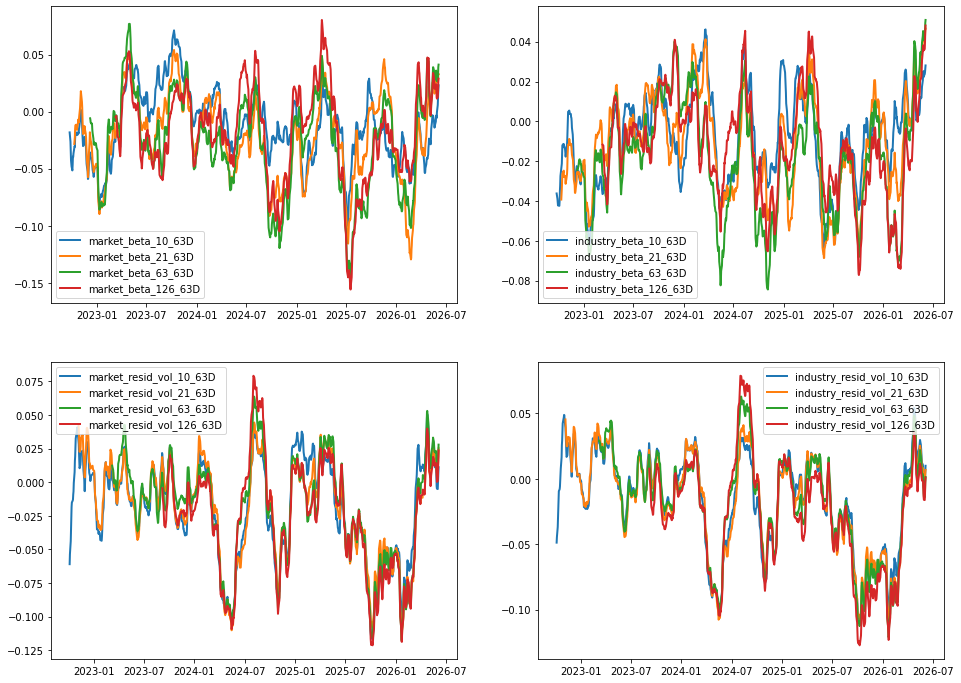

In [9]:
plot_ic_timeseries(beta_ic_dict, "beta")

### Mean Volatility

In [11]:
mv_ic_dict, mv_results_df = ic_dict["mean_volatility"], ic_results_dict["mean_volatility"]

In [12]:
plot_ic_timeseries(mv_ic_dict, "mean_volatility")

KeyError: 'mean_volatility'

### Microstructure

In [20]:
microstructure_ic_dict, microstructure_results_df = ic_dict["microstructure"], ic_results_dict["microstructure"]

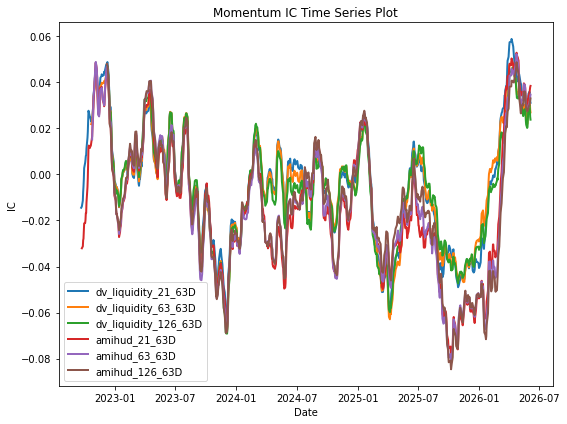

In [21]:
plot_ic_timeseries(microstructure_ic_dict, title='Momentum IC Time Series Plot')

### Momentum

In [13]:
momentum_ic_dict, momentum_results_df = ic_dict["momentum"], ic_results_dict["momentum"]

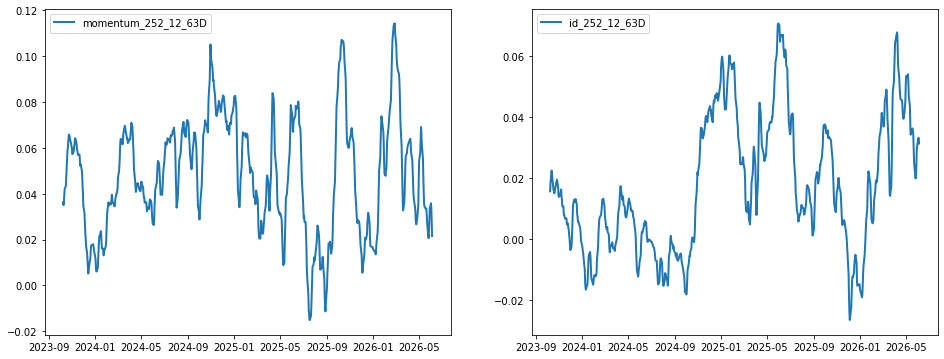

In [14]:
plot_ic_timeseries(momentum_ic_dict, "momentum")

### Reversal

In [15]:
reversal_ic_dict, reversal_results_df = ic_dict["reversal"], ic_results_dict["reversal"]

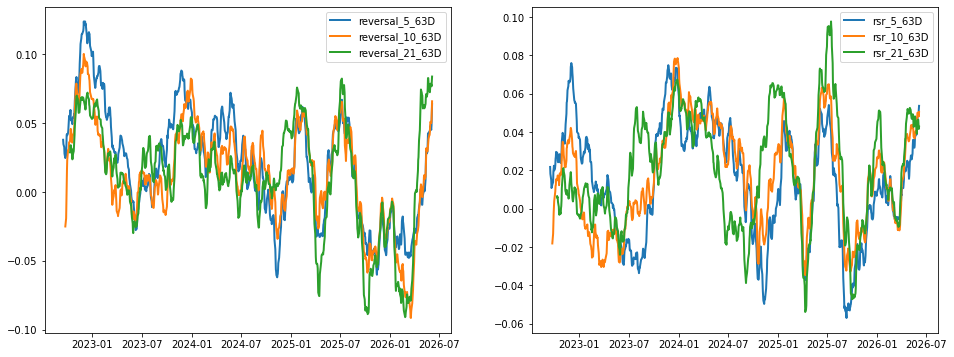

In [17]:
plot_ic_timeseries(reversal_ic_dict, "reversal")

### PVO

In [18]:
pvo_ic_dict, pvo_results_df = ic_dict["pvo"], ic_results_dict["pvo"]

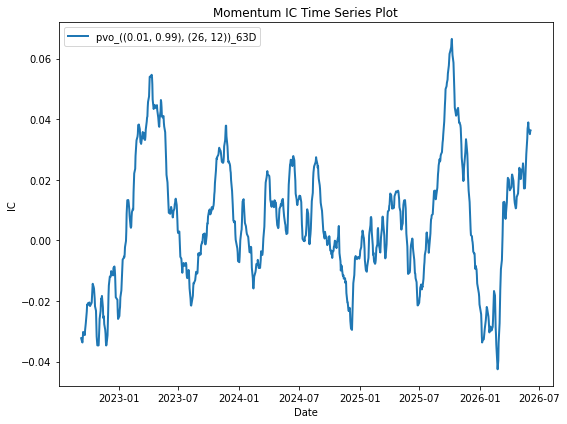

In [19]:
plot_ic_timeseries(pvo_ic_dict, title='Momentum IC Time Series Plot')

### Reversal Illiquidity

In [ ]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

In [31]:
reversal_ic_dict["reversal_10"]

{'reversal_5': {...},
 'reversal_10': {...},
 'reversal_21': {...},
 'rsr_5': {...},
 'rsr_10': {...},
 'rsr_21': {...}}

<AxesSubplot:>

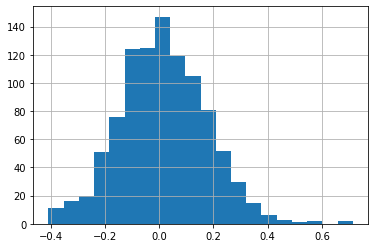

In [16]:
reversal_ic_dict["reversal_21"].hist(bins=20)

In [18]:
IC(returns_df, factors_df_dict["momentum_liquidity"]).run_data()

({'momentum_liquidity_21':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_21  future_return_5d  0.107145
  1   2023-07-14  momentum_liquidity_21  future_return_5d  0.002506
  2   2023-07-17  momentum_liquidity_21  future_return_5d -0.016175
  3   2023-07-18  momentum_liquidity_21  future_return_5d  0.011867
  4   2023-07-19  momentum_liquidity_21  future_return_5d  0.061042
  ..         ...                    ...               ...       ...
  729 2026-05-29  momentum_liquidity_21  future_return_5d -0.059243
  730 2026-06-01  momentum_liquidity_21  future_return_5d -0.145856
  731 2026-06-02  momentum_liquidity_21  future_return_5d -0.261944
  732 2026-06-03  momentum_liquidity_21  future_return_5d -0.287476
  733 2026-06-04  momentum_liquidity_21  future_return_5d -0.228393
  
  [734 rows x 4 columns],
  'momentum_liquidity_63':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_

In [8]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [9]:
IC(returns_df, factors_df_dict["reversal"]).run_data()

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


In [11]:
IC(returns_df, factors_df_dict["reversal_illiquidity"]).run_data()

,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)","reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)","reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
mean_ic,0.000906,0.002136,0.004395,-0.005545,-0.003548,-0.000557,-0.002796,-0.003191,-0.001153
std_ic,0.137560,0.138776,0.138489,0.143973,0.145102,0.143113,0.142457,0.145326,0.144678
ic_ir,0.006588,0.015390,0.031733,-0.038513,-0.024449,-0.003893,-0.019629,-0.021957,-0.007972
positive_ic_rate,0.491474,0.494877,0.501059,0.484453,0.483607,0.495763,0.489858,0.495902,0.502119
n_periods,997.000000,976.000000,944.000000,997.000000,976.000000,944.000000,986.000000,976.000000,944.000000
